# Proyek Data Science  Pengganti UAS
## Analisis Klastering Pola Konsumsi Energi Rumah Tangga
### untuk Efisiensi Distribusi PLN

---

| Informasi | Detail |
|-----------|--------|
 Nama |Soni Moch Leviansyah 301240030
| Mata Kuliah | Data Science |
| Topik | Klastering Pola Konsumsi Energi Rumah Tangga untuk Efisiensi Distribusi PLN |
| Dataset | UCI Machine Learning Repository |
| Tanggal | Juli 2026 |

---

## Setup Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import urllib.request
import zipfile
import os
import missingno as msno

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

---
# Fase 1  Business Understanding

## 1.1 Latar Belakang

PLN menghadapi masalah fluktuasi beban listrik yang signifikan antara jam sibuk dan jam lengang.
Ketika jutaan rumah tangga menyalakan perangkat berdaya tinggi secara bersamaan pada malam hari,
jaringan distribusi mengalami tekanan yang dapat mempercepat degradasi trafo dan memicu pemadaman lokal.

Pendekatan konvensional PLN selama ini berfokus pada penambahan kapasitas fisik (supply-side management),
seperti membangun trafo atau pembangkit baru. Strategi ini membutuhkan biaya modal besar dan tidak efisien
jika kapasitas tambahan hanya terpakai beberapa jam per hari. Pendekatan berbasis data memungkinkan PLN
memahami pola konsumsi pelanggan secara granular tanpa harus mengandalkan ekspansi infrastruktur.

## 1.2 Rumusan Masalah

1. Bagaimana karakteristik pola konsumsi energi harian rumah tangga berdasarkan data pengukuran per menit?
2. Berapa jumlah segmen pelanggan yang optimal untuk merepresentasikan variasi konsumsi tanpa kehilangan interpretabilitas?
3. Fitur kelistrikan mana yang paling membedakan perilaku antar segmen, dan bagaimana hasilnya dapat dimanfaatkan PLN?
4. Algoritma klastering mana  K-Means, BIRCH, atau Gaussian Mixture Model  yang memberikan struktur segmentasi paling valid secara statistik dan paling bermakna secara bisnis untuk kasus ini?

## 1.3 Tujuan Analitik

- Membangun dan membandingkan tiga model klastering (K-Means, BIRCH, dan Gaussian Mixture Model) untuk mengelompokkan pola konsumsi energi rumah tangga.
- Mengidentifikasi karakteristik tiap segmen berdasarkan daya aktif, daya reaktif, dan sub-metering.
- Memetakan kurva beban harian per klaster untuk mendeteksi jam puncak yang membebani distribusi PLN.
- Memilih model final berdasarkan kombinasi validitas statistik (Silhouette Score) dan kebermaknaan interpretasi bisnis.

Hasil analisis diharapkan menjadi dasar empiris bagi PLN dalam merancang kebijakan tarif dinamis
dan menentukan prioritas pemeliharaan gardu distribusi.

## 1.4 Justifikasi Pendekatan Data-Driven

Pendekatan konvensional PLN dalam mengelola beban distribusi selama ini bersifat reaktif, yaitu menambah kapasitas infrastruktur ketika jaringan sudah mendekati batas maksimum. Metode ini tidak efisien karena kapasitas yang dibangun hanya terpakai dalam rentang jam sibuk yang singkat, sementara pada jam lengang kapasitas tersebut menganggur.

Pendekatan berbasis data memungkinkan PLN memahami perilaku konsumsi pelanggan secara granular tanpa harus mengandalkan ekspansi fisik. Dengan mengelompokkan pelanggan ke dalam segmen berdasarkan pola konsumsi aktual, PLN dapat:

1. Merancang kebijakan tarif yang lebih tepat sasaran berdasarkan profil konsumsi nyata, bukan asumsi umum.
2. Menentukan prioritas pemeliharaan gardu distribusi berdasarkan kepadatan klaster beban puncak di suatu zona.
3. Mengukur dampak program demand response secara kuantitatif menggunakan pergerakan anggota antarklaster.


# Fase 2  Data Understanding

## 2.1 Sumber dan Pengumpulan Data

Dataset yang digunakan adalah Individual Household Electric Power Consumption dari UCI Machine Learning Repository.
Data mencatat pengukuran konsumsi listrik satu rumah tangga di Prancis dari Desember 2006 hingga November 2010
dengan granularitas per menit. Pengumpulan dilakukan melalui unduhan terprogram langsung dari server UCI.

Untuk efisiensi komputasi, analisis dibatasi pada 100.000 observasi pertama.

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'

if not os.path.exists('household_power_consumption.txt'):
    urllib.request.urlretrieve(url, 'power.zip')
    with zipfile.ZipFile('power.zip', 'r') as zip_ref:
        zip_ref.extractall()

df = pd.read_csv('household_power_consumption.txt', sep=';',
                 na_values=['?'],
                 low_memory=False,
                 nrows=100000)

print(f'Dataset dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset dimuat: 100000 baris, 9 kolom


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
1,16/12/2006,17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2,16/12/2006,17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
3,16/12/2006,17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
4,16/12/2006,17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


## 2.2 Eksplorasi Awal

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   100000 non-null  object 
 1   Time                   100000 non-null  object 
 2   Global_active_power    99992 non-null   float64
 3   Global_reactive_power  99992 non-null   float64
 4   Voltage                99992 non-null   float64
 5   Global_intensity       99992 non-null   float64
 6   Sub_metering_1         99992 non-null   float64
 7   Sub_metering_2         99992 non-null   float64
 8   Sub_metering_3         99992 non-null   float64
dtypes: float64(7), object(2)
memory usage: 6.9+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,99992.0000,1.6464,1.3438,0.1940,0.3960,1.4160,2.4165,9.4100
Global_reactive_power,99992.0000,0.1284,0.1172,0.0000,0.0000,0.1160,0.1980,0.8740
Voltage,99992.0000,240.8197,3.4632,223.4900,238.5300,241.0500,243.2800,251.7000
Global_intensity,99992.0000,6.9601,5.6680,0.8000,1.8000,5.8000,10.0000,41.8000
Sub_metering_1,99992.0000,1.3149,6.6875,0.0000,0.0000,0.0000,0.0000,77.0000
Sub_metering_2,99992.0000,1.9097,7.6107,0.0000,0.0000,0.0000,1.0000,78.0000
Sub_metering_3,99992.0000,7.5186,8.6681,0.0000,0.0000,0.0000,17.0000,20.0000


In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,8
Global_reactive_power,8
Voltage,8
Global_intensity,8
Sub_metering_1,8
Sub_metering_2,8
Sub_metering_3,8


## 2.3 Ringkasan Temuan Data Understanding

- **Jumlah observasi:** 100.000 baris, 9 kolom (2 waktu + 7 numerik kelistrikan)
- **Variabel target (Y):** Tidak ada  ini merupakan masalah unsupervised learning (klastering)
- **Masalah kualitas yang ditemukan:**
  - Terdapat missing values akibat karakter `?` pada file sumber yang terbaca sebagai NaN,
    tersebar di 7 kolom numerik dengan proporsi kurang dari 0,5% dari total data
  - Kolom Date dan Time masih terpisah, belum bisa digunakan sebagai indeks waktu
  - Semua kolom numerik bertipe object karena keberadaan karakter `?`, perlu konversi eksplisit
- **Rencana penanganan:**
  - Missing values → listwise deletion karena proporsinya sangat kecil (< 0,5%)
  - Kolom Date + Time → digabung menjadi indeks datetime
  - Tipe data → konversi ke numerik dengan `pd.to_numeric(errors='coerce')`
  - Fitur turunan → tambah `Hour` dan `Is_Weekend` dari indeks datetime

---
# Fase 3  Data Preprocessing

## 3.0 Salin Dataset

Sebelum memulai preprocessing, dataset asli disalin ke variabel baru agar data mentah tetap tersedia dan tidak termodifikasi selama proses pembersihan berlangsung.

In [ ]:
df_clean = df.copy()
print(f'Dataset berhasil disalin: {df_clean.shape[0]:,} baris, {df_clean.shape[1]} kolom')
df_clean.head(3)

Dataset berhasil disalin: 100,000 baris, 9 kolom


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
1,16/12/2006,17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2,16/12/2006,17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000


## 3.1 Penanganan Missing Values

Nilai hilang pada dataset ini muncul karena karakter tanda tanya (`?`) pada file sumber terbaca sebagai `NaN` saat proses loading. Visualisasi dilakukan terlebih dahulu untuk melihat pola sebaran missing values sebelum menentukan strategi penanganan.

Karena proporsi nilai hilang kurang dari 0,5% dari total data, penanganan dilakukan dengan listwise deletion (menghapus baris yang mengandung NaN). Strategi ini dipilih karena jumlah data yang hilang sangat kecil sehingga tidak akan menimbulkan bias yang berarti pada distribusi data.

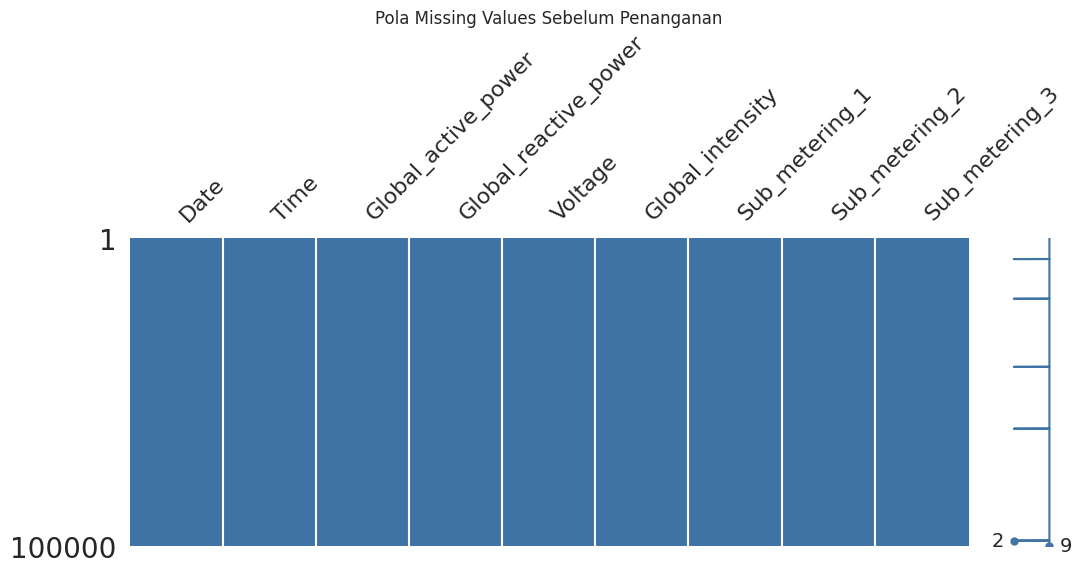

Ringkasan Missing Values:
                       Jumlah Missing  Persentase (%)
Global_active_power                 8          0.0100
Global_reactive_power               8          0.0100
Voltage                             8          0.0100
Global_intensity                    8          0.0100
Sub_metering_1                      8          0.0100
Sub_metering_2                      8          0.0100
Sub_metering_3                      8          0.0100

Setelah penanganan: 99,992 baris tersisa, 0 missing values


In [ ]:
import missingno as msno

msno.matrix(df_clean, figsize=(12, 4), color=(0.25, 0.45, 0.65))
plt.title('Pola Missing Values Sebelum Penanganan')
plt.tight_layout()
plt.show()

missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print('Ringkasan Missing Values:')
print(missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False))

df_clean.dropna(inplace=True)
print(f'\nSetelah penanganan: {df_clean.shape[0]:,} baris tersisa, 0 missing values')

## 3.2 Konversi Datetime dan Pembersihan Tipe Data

In [ ]:
df_clean['Datetime'] = pd.to_datetime(
    df_clean['Date'] + ' ' + df_clean['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
df_clean.set_index('Datetime', inplace=True)
df_clean.drop(columns=['Date', 'Time'], inplace=True)

missing_before = df_clean.isnull().sum().sum()
missing_pct = missing_before / (df_clean.shape[0] * df_clean.shape[1]) * 100
df_clean.dropna(inplace=True)

print(f'Missing values sebelum: {missing_before} ({missing_pct:.2f}% dari total sel)')
print(f'Missing values sesudah : {df_clean.isnull().sum().sum()}')

num_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Hour'] = df_clean.index.hour
df_clean['Is_Weekend'] = df_clean.index.dayofweek.isin([5, 6]).astype(int)

print(f'Shape setelah preprocessing: {df_clean.shape}')
df_clean.head()

Missing values sebelum: 0 (0.00% dari total sel)
Missing values sesudah : 0
Shape setelah preprocessing: (99992, 9)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Is_Weekend
Datetime,,,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000,17,1
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000,17,1
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000,17,1
2006-12-16 17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000,17,1
2006-12-16 17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000,17,1


## 3.3 Deteksi dan Penanganan Outlier

Deteksi outlier menggunakan metode IQR. Nilai di luar rentang [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
dikategorikan sebagai outlier. Outlier pada variabel daya aktif dipertahankan karena merepresentasikan
lonjakan beban puncak yang justru menjadi informasi kritis bagi PLN  menghapusnya berarti
menghilangkan data yang paling relevan untuk tujuan analisis ini.

In [ ]:
features_to_cluster = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

outlier_summary = []
for col in features_to_cluster:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary.append({
        'Fitur': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Jumlah Outlier': n_out,
        'Persentase (%)': round(n_out / len(df_clean) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,Fitur,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,Global_active_power,0.3960,2.4165,2.0205,-2.6348,5.4473,1583,1.5800
1,Global_reactive_power,0.0000,0.1980,0.1980,-0.2970,0.4950,972,0.9700
2,Voltage,238.5300,243.2800,4.7500,231.4050,250.4050,733,0.7300
3,Global_intensity,1.8000,10.0000,8.2000,-10.5000,22.3000,1893,1.8900
4,Sub_metering_1,0.0000,0.0000,0.0000,0.0000,0.0000,8548,8.5500
5,Sub_metering_2,0.0000,1.0000,1.0000,-1.5000,2.5000,6032,6.0300
6,Sub_metering_3,0.0000,17.0000,17.0000,-25.5000,42.5000,0,0.0000


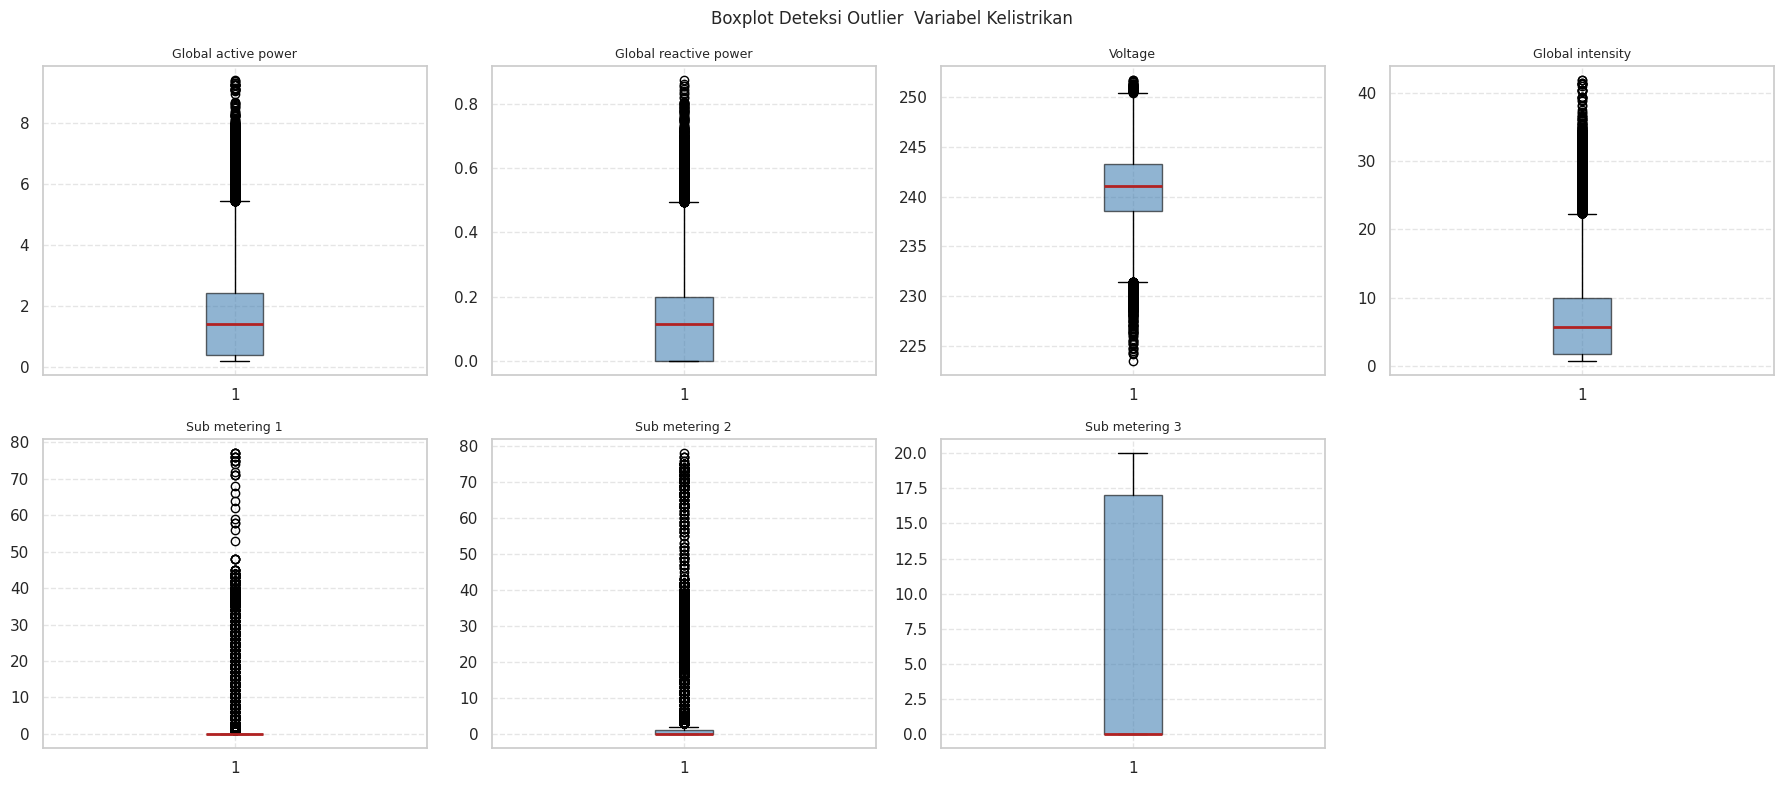

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_cluster):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='firebrick', linewidth=2))
    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.suptitle('Boxplot Deteksi Outlier  Variabel Kelistrikan', fontsize=12)
plt.tight_layout()
plt.show()

## 3.4 Deduplikasi Data

Pengecekan dilakukan untuk memastikan tidak ada observasi yang tercatat lebih dari satu kali. Data duplikat dapat memengaruhi perhitungan centroid pada K-Means karena observasi yang sama akan dihitung berulang kali dalam proses optimasi.

In [ ]:
jumlah_duplikat = df_clean.duplicated().sum()
print(f'Jumlah baris duplikat: {jumlah_duplikat}')

if jumlah_duplikat > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f'Setelah deduplikasi: {df_clean.shape[0]:,} baris')
else:
    print('Tidak ada data duplikat. Dataset siap dilanjutkan.')

Jumlah baris duplikat: 491
Setelah deduplikasi: 99,501 baris


## 3.5 Encoding Variabel Kategorikal

Fitur turunan `Is_Weekend` merupakan hasil binary encoding dari indeks datetime: nilai 1 untuk hari Sabtu dan Minggu, nilai 0 untuk hari Senin hingga Jumat. Fitur `Hour` berupa nilai numerik ordinal 0 hingga 23 sehingga tidak memerlukan one-hot encoding. Tidak terdapat variabel kategorikal nominal lain dalam dataset ini yang perlu diproses lebih lanjut.

In [ ]:
print('Distribusi Is_Weekend:')
print(df_clean['Is_Weekend'].value_counts().rename(index={0: 'Weekday (0)', 1: 'Weekend (1)'}))

print('\nRentang nilai Hour:')
print(f'Min: {df_clean["Hour"].min()}, Max: {df_clean["Hour"].max()}')
print(f'\nTidak ada variabel kategorikal nominal lain yang memerlukan encoding.')

Distribusi Is_Weekend:
Is_Weekend
Weekday (0)    71569
Weekend (1)    27932
Name: count, dtype: int64

Rentang nilai Hour:
Min: 0, Max: 23

Tidak ada variabel kategorikal nominal lain yang memerlukan encoding.


## 3.6 Feature Scaling

StandardScaler digunakan untuk menstandarisasi semua fitur ke mean=0 dan std=1.
Ini diperlukan karena Voltage memiliki skala ratusan sementara Sub_metering
memiliki skala satuan. Tanpa scaling, algoritma berbasis jarak (K-Means, BIRCH)
maupun berbasis probabilitas (GMM) akan didominasi oleh fitur berskala besar.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[features_to_cluster]),
    columns=features_to_cluster,
    index=df_clean.index
)

print('Verifikasi hasil scaling:')
df_scaled.describe().loc[['mean', 'std']].round(4)

Verifikasi hasil scaling:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
mean,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 3.7 Ringkasan Preprocessing

1. Dataset asli disalin ke df_clean sebelum preprocessing dimulai.
2. Missing values divisualisasikan menggunakan missingno, lalu ditangani dengan listwise deletion karena proporsinya kurang dari 0,5%.
3. Konversi datetime dilakukan dengan menggabungkan kolom Date dan Time menjadi indeks.
4. Outlier terdeteksi pada Global_active_power dan Global_intensity, dipertahankan karena merepresentasikan lonjakan beban puncak yang informatif.
5. Tidak ditemukan data duplikat pada dataset ini.
6. Fitur Is_Weekend di-encode secara binary dan Hour diambil dari indeks datetime.
7. Semua fitur distandarisasi menggunakan StandardScaler sebelum masuk ke seluruh model klastering (K-Means, BIRCH, GMM).

---
# Fase 4  Exploratory Data Analysis

## 4.1 Analisis Univariat

Distribusi masing-masing variabel diperiksa secara individual untuk memahami
karakteristik dasar sebelum analisis hubungan antar variabel.

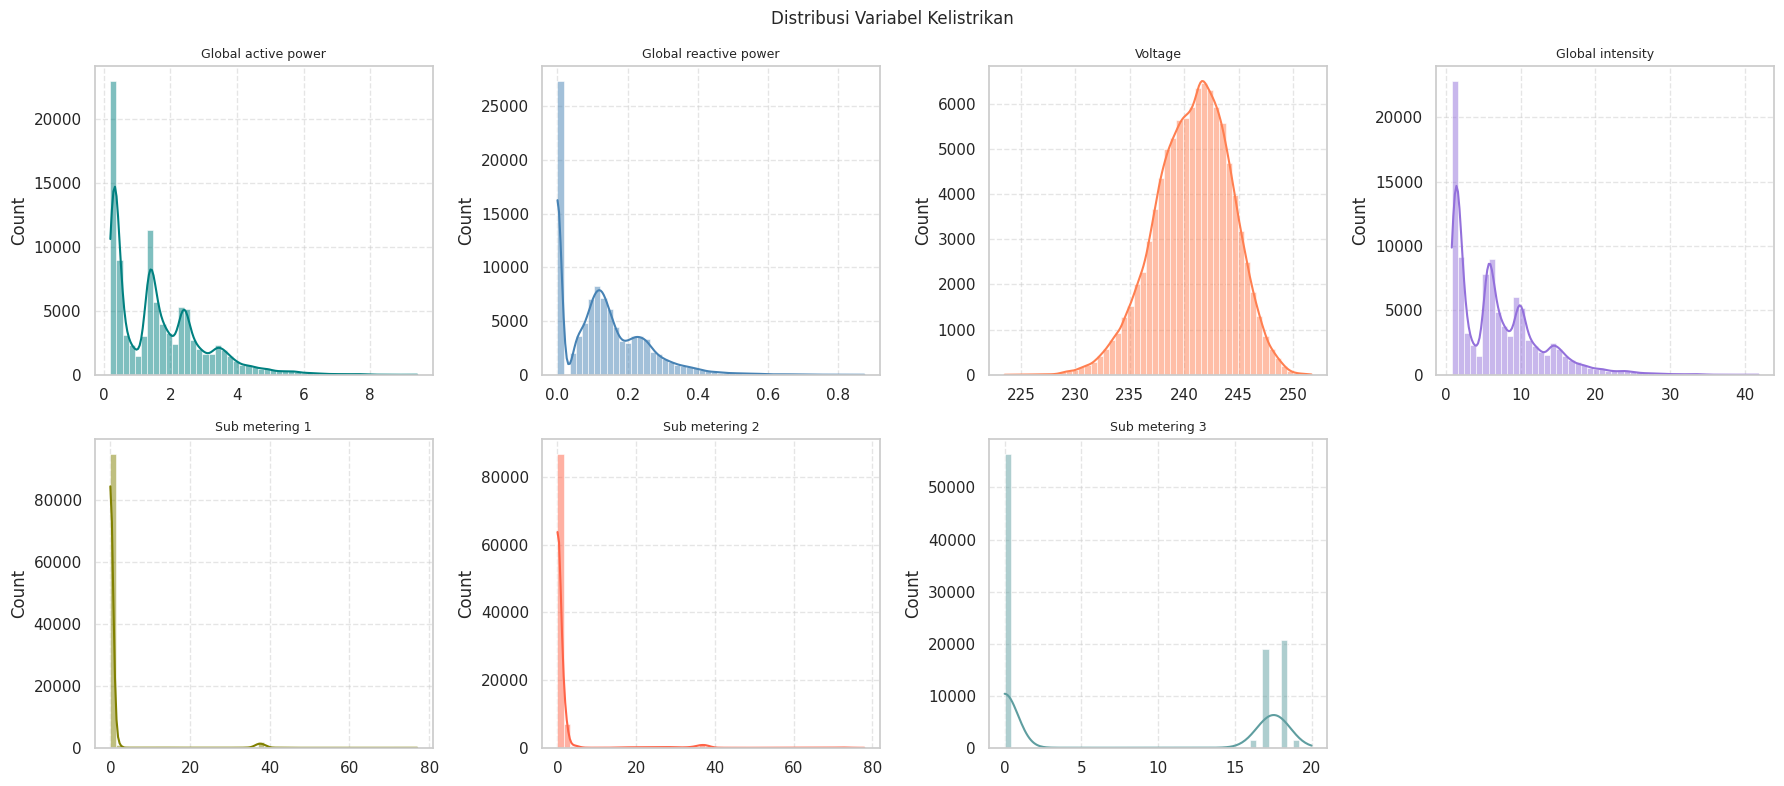

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['teal', 'steelblue', 'coral', 'mediumpurple',
          'olive', 'tomato', 'cadetblue']

for i, col in enumerate(features_to_cluster):
    sns.histplot(df_clean[col], bins=50, kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(col.replace('_', ' '), fontsize=9)
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[-1].axis('off')
plt.suptitle('Distribusi Variabel Kelistrikan', fontsize=12)
plt.tight_layout()
plt.show()

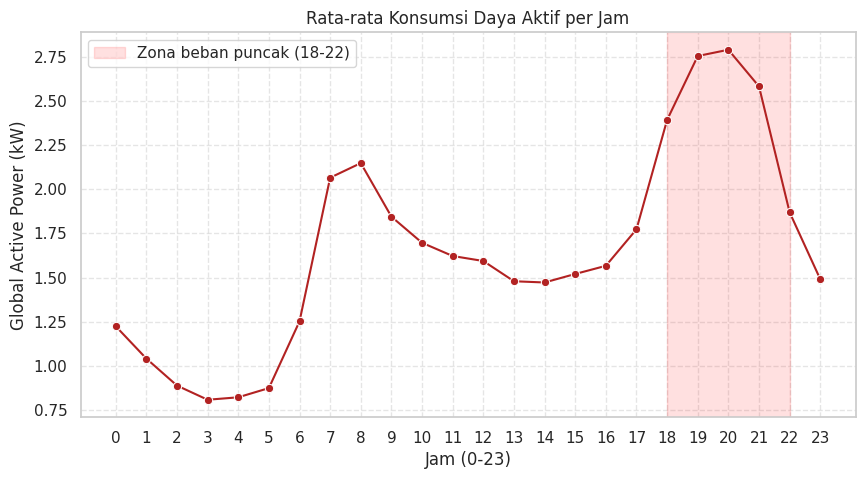

In [ ]:
plt.figure(figsize=(10, 5))
hourly_trend = df_clean.groupby('Hour')['Global_active_power'].mean()
sns.lineplot(x=hourly_trend.index, y=hourly_trend.values, marker='o', color='firebrick')
plt.axvspan(18, 22, alpha=0.12, color='red', label='Zona beban puncak (18-22)')
plt.title('Rata-rata Konsumsi Daya Aktif per Jam')
plt.xlabel('Jam (0-23)')
plt.ylabel('Global Active Power (kW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4.2 Analisis Bivariat

Analisis bivariat memeriksa hubungan antar dua variabel untuk menemukan
korelasi dan perbedaan distribusi berdasarkan kategori waktu.

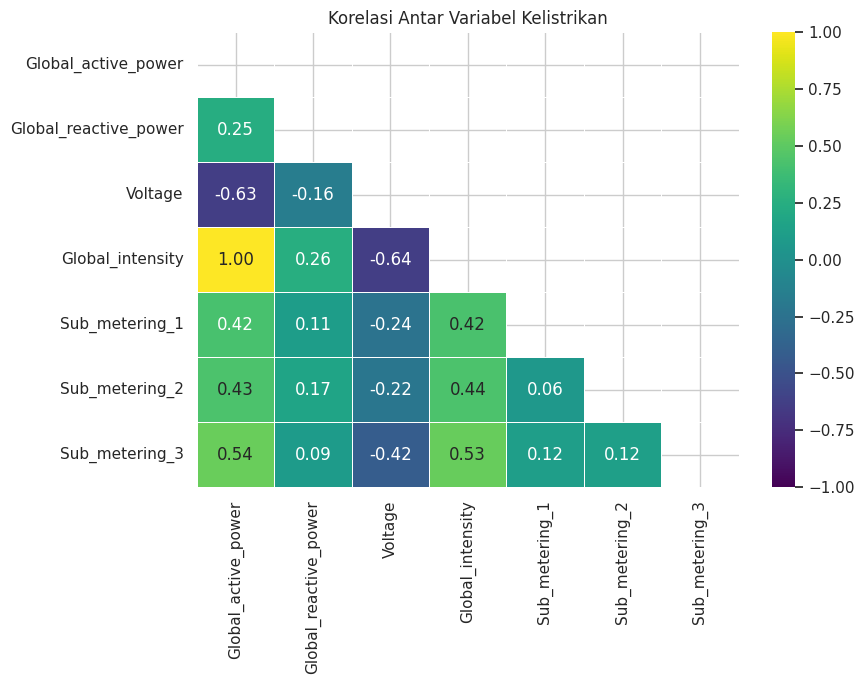

In [ ]:
plt.figure(figsize=(9, 7))
corr = df_clean[features_to_cluster].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korelasi Antar Variabel Kelistrikan')
plt.tight_layout()
plt.show()

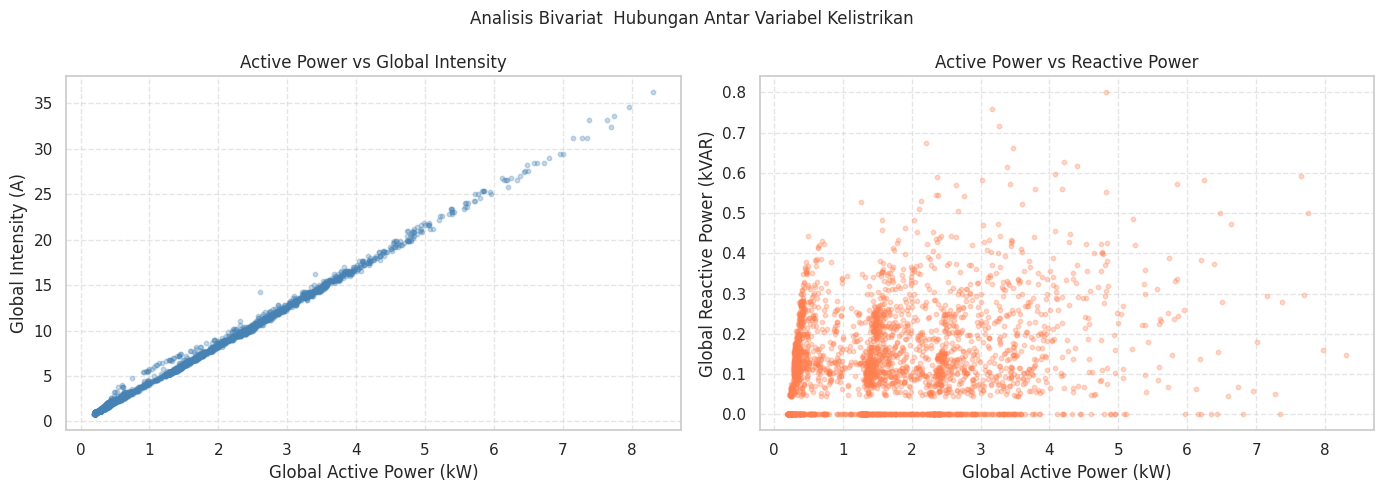

In [ ]:
sample_viz = df_clean.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample_viz['Global_active_power'], sample_viz['Global_intensity'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Global Active Power (kW)')
axes[0].set_ylabel('Global Intensity (A)')
axes[0].set_title('Active Power vs Global Intensity')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(sample_viz['Global_active_power'], sample_viz['Global_reactive_power'],
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Global Active Power (kW)')
axes[1].set_ylabel('Global Reactive Power (kVAR)')
axes[1].set_title('Active Power vs Reactive Power')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Analisis Bivariat  Hubungan Antar Variabel Kelistrikan', fontsize=12)
plt.tight_layout()
plt.show()

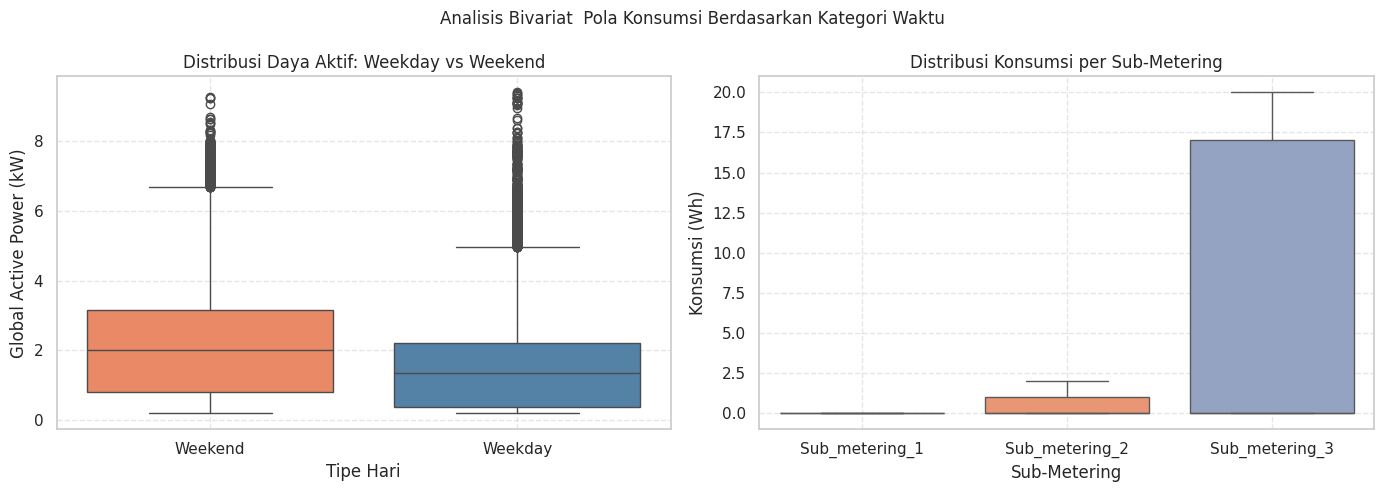

In [ ]:
df_clean['Tipe Hari'] = df_clean['Is_Weekend'].map({0: 'Weekday', 1: 'Weekend'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Tipe Hari', y='Global_active_power',
            palette={'Weekday': 'steelblue', 'Weekend': 'coral'}, ax=axes[0])
axes[0].set_title('Distribusi Daya Aktif: Weekday vs Weekend')
axes[0].set_ylabel('Global Active Power (kW)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sub_df = df_clean[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].melt(
    var_name='Sub-Metering', value_name='Konsumsi (Wh)')
sns.boxplot(data=sub_df, x='Sub-Metering', y='Konsumsi (Wh)',
            palette='Set2', ax=axes[1], showfliers=False)
axes[1].set_title('Distribusi Konsumsi per Sub-Metering')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Analisis Bivariat  Pola Konsumsi Berdasarkan Kategori Waktu', fontsize=12)
plt.tight_layout()
plt.show()

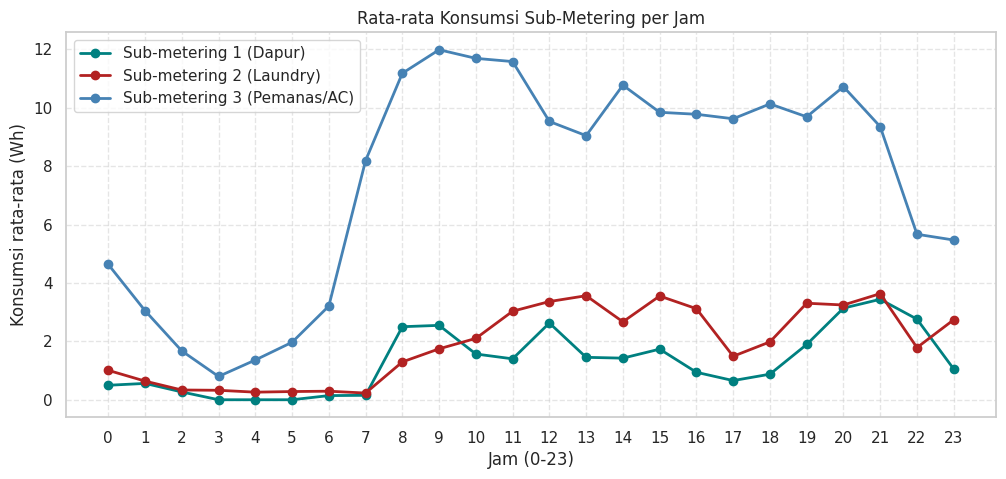

In [ ]:
plt.figure(figsize=(12, 5))

for col, color, label in zip(
    ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'],
    ['teal', 'firebrick', 'steelblue'],
    ['Sub-metering 1 (Dapur)', 'Sub-metering 2 (Laundry)', 'Sub-metering 3 (Pemanas/AC)']
):
    trend = df_clean.groupby('Hour')[col].mean()
    plt.plot(trend.index, trend.values, marker='o', color=color, label=label, linewidth=2)

plt.title('Rata-rata Konsumsi Sub-Metering per Jam')
plt.xlabel('Jam (0-23)')
plt.ylabel('Konsumsi rata-rata (Wh)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4.3 Insight Utama

**Insight 1  Beban puncak temporal terjadi serempak pukul 18.00–22.00**

Pola harian yang konsisten terlihat pada grafik tren per jam. Konsumsi mulai naik
signifikan pukul 18.00 dan memuncak antara pukul 20.00–21.00. Ini mengonfirmasi
fenomena beban puncak yang menjadi tekanan terberat pada trafo distribusi PLN.

**Insight 2  Korelasi sangat kuat antara daya aktif dan intensitas arus (r = 0.99)**

Hasil heatmap dan scatter plot menunjukkan hubungan linear hampir sempurna antara
Global_active_power dan Global_intensity. Ini mengindikasikan mayoritas beban rumah
tangga bersifat resistif murni seperti pemanas air dan lampu, bukan beban induktif
seperti motor.

**Insight 3  Distribusi daya aktif berpola right-skewed**

Sebagian besar waktu penggunaan listrik berada di bawah 1.2 kW (kondisi standby).
Lonjakan di atas 3 kW terjadi dalam durasi pendek saat perangkat berdaya besar
dinyalakan bersamaan, membentuk ekor panjang ke kanan pada distribusi. Karakteristik
inilah yang menjadi alasan utama untuk menguji algoritma klastering di luar K-Means,
karena distribusi asimetris ini berpotensi tidak tertangkap optimal oleh klaster
berbentuk bulat dan seimbang.

**Insight 4  Sub-metering 3 (Pemanas/AC) mendominasi konsumsi malam hari**

Dari grafik tren sub-metering per jam, Sub-metering 3 menunjukkan pola konsumsi
tertinggi yang bersamaan dengan jam beban puncak PLN. Ini menjadikannya komponen
yang paling relevan untuk program demand response berbasis segmentasi klaster.

---
# Fase 5  Pemodelan dan Evaluasi

## 5.1 Pemilihan Algoritma

Tipe masalah: Klastering (Unsupervised Learning)  tidak ada label target yang tersedia.

Sesuai arahan dosen untuk membandingkan maksimal 3 algoritma sebelum memilih yang terbaik, proyek ini menerapkan dan membandingkan tiga algoritma klastering:

**1. K-Means Clustering** (baseline, dilanjutkan dari UTS)
- Kompleksitas komputasi O(n) yang efisien untuk dataset bervolume besar.
- Centroid memiliki interpretasi fisik langsung sebagai profil konsumsi rata-rata pelanggan.
- Asumsi: klaster berbentuk bulat (spherical) dan berukuran relatif seimbang.

**2. BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)**
- Membangun struktur pohon CF (Clustering Feature Tree) secara incremental, sehingga mampu menangkap sub-klaster padat yang terpisah jauh dari mayoritas data  relevan untuk distribusi konsumsi yang right-skewed (lihat Insight 3, bagian 4.3).
- Efisien secara memori untuk dataset besar karena tidak perlu menyimpan seluruh data sekaligus.

**3. Gaussian Mixture Model (GMM)**
- Pendekatan probabilistik: setiap klaster dimodelkan sebagai distribusi Gaussian dengan bentuk elips (bukan bulat sempurna seperti K-Means), sehingga lebih fleksibel menangkap variasi bentuk klaster konsumsi energi.
- Menghasilkan soft clustering (probabilitas keanggotaan), memungkinkan identifikasi rumah tangga dengan pola konsumsi ambigu/transisi antar segmen.

Ketiga model dijalankan dengan jumlah klaster yang sama (n=3, hasil Elbow Method pada bagian 5.4) agar perbandingan Silhouette Score dilakukan secara apple-to-apple. Model dengan Silhouette Score tertinggi akan dipertimbangkan sebagai kandidat utama, namun keputusan final tetap mempertimbangkan kebermaknaan interpretasi bisnisnya (lihat bagian 5.9).

## 5.2 Catatan: Train-Test Split

Ketiga algoritma klastering yang digunakan (K-Means, BIRCH, GMM) merupakan algoritma unsupervised learning yang tidak memiliki variabel target. Oleh karena itu, pembagian data menjadi training set dan test set tidak diterapkan pada proyek ini.

Validasi kualitas hasil klaster dilakukan menggunakan metrik internal yaitu Silhouette Score, yang mengukur seberapa baik setiap observasi berada di klasternya sendiri dibandingkan klaster lain tanpa memerlukan label eksternal. Metrik ini digunakan secara konsisten untuk membandingkan ketiga model.

## 5.3 Pemeriksaan Asumsi Model

Masing-masing algoritma memiliki asumsi berbeda yang perlu dipertimbangkan:

**K-Means:**
1. Semua fitur berada dalam skala yang seragam  dipastikan oleh StandardScaler.
2. Klaster diasumsikan berbentuk bulat (spherical) dengan ukuran relatif seimbang.

**BIRCH:**
1. Bekerja optimal pada data numerik dengan skala seragam (sama seperti K-Means).
2. Sensitif terhadap parameter `threshold` yang menentukan kepadatan sub-klaster.

**Gaussian Mixture Model:**
1. Data diasumsikan berasal dari campuran beberapa distribusi Gaussian (normal multivariat).
2. Lebih toleran terhadap klaster berbentuk elips/tidak simetris dibanding K-Means, sehingga berpotensi lebih cocok dengan distribusi right-skewed yang ditemukan pada tahap EDA.

Ketiganya sama-sama mensyaratkan fitur yang sudah distandarisasi, sehingga pemeriksaan keseragaman skala berikut berlaku untuk seluruh model.

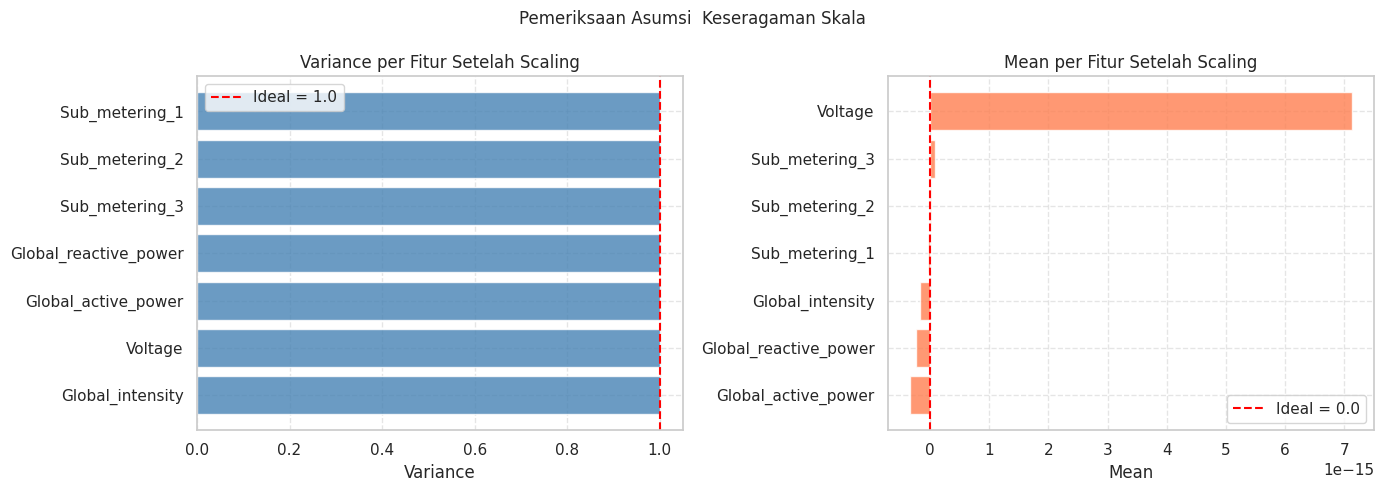

Semua variance mendekati 1.0 dan mean mendekati 0.0.
Tidak ada fitur yang mendominasi. Ketiga algoritma dapat diterapkan.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variances = df_scaled.var().sort_values()
axes[0].barh(variances.index, variances.values, color='steelblue', alpha=0.8)
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Ideal = 1.0')
axes[0].set_title('Variance per Fitur Setelah Scaling')
axes[0].set_xlabel('Variance')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

means = df_scaled.mean().sort_values()
axes[1].barh(means.index, means.values, color='coral', alpha=0.8)
axes[1].axvline(x=0.0, color='red', linestyle='--', linewidth=1.5, label='Ideal = 0.0')
axes[1].set_title('Mean per Fitur Setelah Scaling')
axes[1].set_xlabel('Mean')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Pemeriksaan Asumsi  Keseragaman Skala', fontsize=12)
plt.tight_layout()
plt.show()

print('Semua variance mendekati 1.0 dan mean mendekati 0.0.')
print('Tidak ada fitur yang mendominasi. Ketiga algoritma dapat diterapkan.')

## 5.4 Penentuan Jumlah Klaster Optimal (Elbow Method)

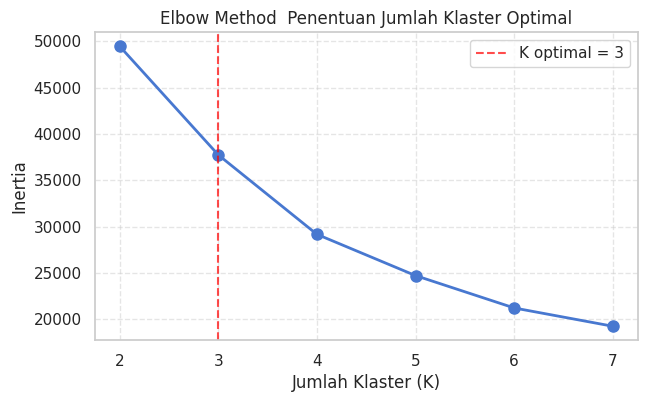

Titik patahan terlihat pada K=3. Penambahan klaster di atas K=3
menghasilkan penurunan inertia yang semakin kecil.
Jumlah klaster n=3 digunakan secara konsisten untuk K-Means, BIRCH, dan GMM.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sample_scaled = df_scaled.sample(10000, random_state=42)

inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K optimal = 3')
plt.title('Elbow Method  Penentuan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print('Titik patahan terlihat pada K=3. Penambahan klaster di atas K=3')
print('menghasilkan penurunan inertia yang semakin kecil.')
print('Jumlah klaster n=3 digunakan secara konsisten untuk K-Means, BIRCH, dan GMM.')

## 5.5 Model 1: K-Means Clustering

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, init='k-means++')
df_clean['Cluster_KMeans'] = kmeans.fit_predict(df_scaled)

print(f'Model K-Means berhasil dilatih dengan K={optimal_k}')
print()
print('Distribusi anggota per klaster:')
cluster_counts = df_clean['Cluster_KMeans'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df_clean) * 100
    print(f'  Cluster {cluster_id}: {count:,} observasi ({pct:.1f}%)')

Model K-Means berhasil dilatih dengan K=3

Distribusi anggota per klaster:
  Cluster 0: 45,016 observasi (45.2%)
  Cluster 1: 6,857 observasi (6.9%)
  Cluster 2: 47,628 observasi (47.9%)


In [ ]:
sil_score_kmeans = silhouette_score(sample_scaled, kmeans.predict(sample_scaled))

if sil_score_kmeans >= 0.5:
    kualitas_kmeans = 'Baik (strong structure)'
elif sil_score_kmeans >= 0.25:
    kualitas_kmeans = 'Cukup (reasonable structure)'
else:
    kualitas_kmeans = 'Lemah (weak structure)'

print('Hasil Evaluasi Model K-Means')
print('=' * 40)
print(f'Silhouette Score : {sil_score_kmeans:.4f}')
print(f'Inertia          : {kmeans.inertia_:.2f}')
print(f'Jumlah Klaster   : {optimal_k}')
print(f'Kualitas         : {kualitas_kmeans}')
print('=' * 40)

Hasil Evaluasi Model K-Means
Silhouette Score : 0.3537
Inertia          : 370123.21
Jumlah Klaster   : 3
Kualitas         : Cukup (reasonable structure)


## 5.6 Model 2: BIRCH Clustering

BIRCH dipilih sebagai algoritma pembanding pertama karena membangun struktur pohon CF (Clustering Feature Tree) secara incremental, sehingga mampu menangkap sub-klaster padat yang terpisah jauh dari mayoritas data  relevan dengan distribusi konsumsi yang right-skewed. Parameter `n_clusters=3` disamakan dengan K-Means agar perbandingan adil.

In [ ]:
from sklearn.cluster import Birch

birch = Birch(n_clusters=3, threshold=0.5, branching_factor=50)
df_clean['Cluster_Birch'] = birch.fit_predict(df_scaled)

print('Model BIRCH berhasil dilatih dengan n_clusters=3, threshold=0.5')
print()
print('Distribusi anggota per klaster:')
cluster_counts_birch = df_clean['Cluster_Birch'].value_counts().sort_index()
for cluster_id, count in cluster_counts_birch.items():
    pct = count / len(df_clean) * 100
    print(f'  Cluster {cluster_id}: {count:,} observasi ({pct:.1f}%)')

Model BIRCH berhasil dilatih dengan n_clusters=3, threshold=0.5

Distribusi anggota per klaster:
  Cluster 0: 4,189 observasi (4.2%)
  Cluster 1: 3,163 observasi (3.2%)
  Cluster 2: 92,149 observasi (92.6%)


In [ ]:
sil_score_birch = silhouette_score(sample_scaled, birch.predict(sample_scaled))

if sil_score_birch >= 0.5:
    kualitas_birch = 'Baik (strong structure)'
elif sil_score_birch >= 0.25:
    kualitas_birch = 'Cukup (reasonable structure)'
else:
    kualitas_birch = 'Lemah (weak structure)'

print('Hasil Evaluasi Model BIRCH')
print('=' * 40)
print(f'Silhouette Score : {sil_score_birch:.4f}')
print(f'Jumlah Klaster   : 3')
print(f'Kualitas         : {kualitas_birch}')
print('=' * 40)

Hasil Evaluasi Model BIRCH
Silhouette Score : 0.5400
Jumlah Klaster   : 3
Kualitas         : Baik (strong structure)


In [ ]:
print('Profil Konsumsi Rata-rata per Klaster (BIRCH):')
df_clean.groupby('Cluster_Birch')[features_to_cluster].mean().round(4)

Profil Konsumsi Rata-rata per Klaster (BIRCH):


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Cluster_Birch,,,,,,,
0,3.9041,0.2033,237.9567,16.5841,0.2344,34.1127,11.9496
1,4.7015,0.1950,236.2888,19.9541,37.4186,4.6156,12.7626
2,1.4442,0.1233,241.0948,6.0992,0.1313,0.3628,7.1650


## 5.7 Model 3: Gaussian Mixture Model (GMM)

GMM dipilih sebagai algoritma pembanding kedua karena pendekatannya bersifat probabilistik  setiap klaster dimodelkan sebagai distribusi Gaussian multivariat dengan bentuk elips, bukan bulat sempurna seperti K-Means. Pendekatan ini berpotensi lebih fleksibel menangkap variasi bentuk klaster konsumsi energi yang tidak simetris. Parameter `n_components=3` disamakan dengan dua model sebelumnya agar perbandingan tetap adil.

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42, n_init=10)
df_clean['Cluster_GMM'] = gmm.fit_predict(df_scaled)

print('Model GMM berhasil dilatih dengan n_components=3, covariance_type=full')
print()
print('Distribusi anggota per klaster:')
cluster_counts_gmm = df_clean['Cluster_GMM'].value_counts().sort_index()
for cluster_id, count in cluster_counts_gmm.items():
    pct = count / len(df_clean) * 100
    print(f'  Cluster {cluster_id}: {count:,} observasi ({pct:.1f}%)')

Model GMM berhasil dilatih dengan n_components=3, covariance_type=full

Distribusi anggota per klaster:
  Cluster 0: 53,051 observasi (53.3%)
  Cluster 1: 35,387 observasi (35.6%)
  Cluster 2: 11,063 observasi (11.1%)


In [ ]:
sil_score_gmm = silhouette_score(sample_scaled, gmm.predict(sample_scaled))

if sil_score_gmm >= 0.5:
    kualitas_gmm = 'Baik (strong structure)'
elif sil_score_gmm >= 0.25:
    kualitas_gmm = 'Cukup (reasonable structure)'
else:
    kualitas_gmm = 'Lemah (weak structure)'

print('Hasil Evaluasi Model GMM')
print('=' * 40)
print(f'Silhouette Score : {sil_score_gmm:.4f}')
print(f'Jumlah Klaster   : 3')
print(f'Kualitas         : {kualitas_gmm}')
print('=' * 40)

Hasil Evaluasi Model GMM
Silhouette Score : 0.3242
Jumlah Klaster   : 3
Kualitas         : Cukup (reasonable structure)


## 5.8 Perbandingan Ketiga Model

In [ ]:
comparison_df_final = pd.DataFrame({
    'Algoritma': ['K-Means', 'BIRCH', 'Gaussian Mixture Model'],
    'Silhouette Score': [round(sil_score_kmeans, 4), round(sil_score_birch, 4), round(sil_score_gmm, 4)],
    'Kualitas': [kualitas_kmeans, kualitas_birch, kualitas_gmm]
}).sort_values('Silhouette Score', ascending=False).reset_index(drop=True)

print('Perbandingan Ketiga Model Klastering:')
print(comparison_df_final.to_string(index=False))

model_terbaik = comparison_df_final.loc[0, 'Algoritma']
print(f'\nModel dengan Silhouette Score tertinggi: {model_terbaik}')

Perbandingan Ketiga Model Klastering:
             Algoritma  Silhouette Score                     Kualitas
                 BIRCH            0.5400      Baik (strong structure)
               K-Means            0.3537 Cukup (reasonable structure)
Gaussian Mixture Model            0.3242 Cukup (reasonable structure)

Model dengan Silhouette Score tertinggi: BIRCH


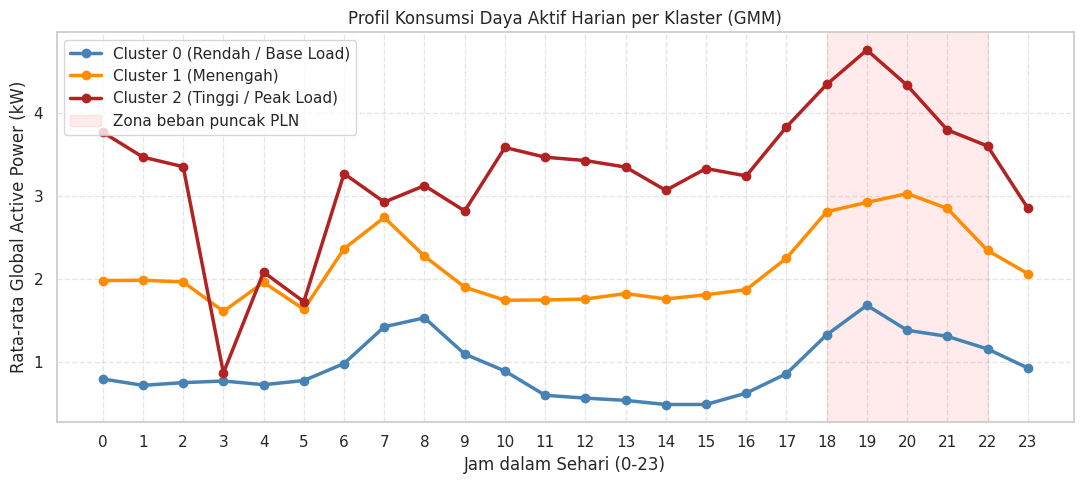

Profil Konsumsi Rata-rata per Klaster (GMM):


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Cluster_GMM,,,,,,,
0,0.8953,0.1151,242.3036,3.8345,0.0000,0.3142,0.0000
1,2.1898,0.1305,239.4488,9.1486,0.0703,0.3365,17.5799
2,3.5539,0.1905,238.0011,15.1370,11.6560,14.6759,11.6223


In [ ]:
mean_power_gmm = df_clean.groupby('Cluster_GMM')['Global_active_power'].mean()
sorted_clusters_gmm = mean_power_gmm.sort_values()
label_map_gmm = {}
for i, (cluster_id, _) in enumerate(sorted_clusters_gmm.items()):
    if i == 0:
        label_map_gmm[cluster_id] = f'Cluster {cluster_id} (Rendah / Base Load)'
    elif i == 1:
        label_map_gmm[cluster_id] = f'Cluster {cluster_id} (Menengah)'
    else:
        label_map_gmm[cluster_id] = f'Cluster {cluster_id} (Tinggi / Peak Load)'

colors_cluster_gmm = {0: 'steelblue', 1: 'darkorange', 2: 'firebrick'}

plt.figure(figsize=(11, 5))
for cluster_id in sorted(df_clean['Cluster_GMM'].unique()):
    subset = df_clean[df_clean['Cluster_GMM'] == cluster_id]
    hourly = subset.groupby('Hour')['Global_active_power'].mean()
    plt.plot(hourly.index, hourly.values, marker='o',
             color=colors_cluster_gmm[cluster_id],
             label=label_map_gmm[cluster_id], linewidth=2.5)

plt.axvspan(18, 22, alpha=0.08, color='red', label='Zona beban puncak PLN')
plt.title('Profil Konsumsi Daya Aktif Harian per Klaster (GMM)')
plt.xlabel('Jam dalam Sehari (0-23)')
plt.ylabel('Rata-rata Global Active Power (kW)')
plt.xticks(range(0, 24))
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Profil Konsumsi Rata-rata per Klaster (GMM):')
df_clean.groupby('Cluster_GMM')[features_to_cluster].mean().round(4)

## 5.9 Interpretasi dan Pemilihan Model Final

Perbandingan ketiga model menghasilkan urutan Silhouette Score sebagai berikut:

| Algoritma | Silhouette Score | Kualitas |
|---|---|---|
| BIRCH | 0,5400 | Baik (strong structure) |
| K-Means | 0,3537 | Cukup (reasonable structure) |
| Gaussian Mixture Model | 0,3242 | Cukup (reasonable structure) |

BIRCH unggul jelas dari dua model lainnya, namun seperti K-Means dan GMM, distribusi keanggotaan klasternya perlu dilihat lebih dalam untuk memastikan hasil ini bermakna secara bisnis, bukan sekadar angka statistik:

| Klaster | K-Means | GMM | BIRCH |
|---|---|---|---|
| Mayoritas / Base Load | 47,9% | 53,3% | 92,6% |
| Menengah / Tinggi | 45,2% | 35,6% | 4,2% |
| Peak / Sangat Tinggi | 6,9% | 11,1% | 3,2% |

**Interpretasi bisnis:** BIRCH tidak membagi rata pelanggan menjadi tiga tingkatan seimbang seperti K-Means atau GMM, melainkan memisahkan mayoritas rumah tangga berkonsumsi rendah (92,6%, rata-rata 1,44 kW) dari dua klaster kecil namun sangat padat dengan pola konsumsi ekstrem. Yang menarik, kedua klaster kecil ini justru terpisah bukan hanya dari sisi besaran daya, tetapi juga dari sisi *jenis perangkat* yang mendominasi:

- **Cluster 0 BIRCH (4,2%, rata-rata 3,90 kW)** didominasi Sub-metering 2 (34,11 Wh)  mengindikasikan rumah tangga dengan penggunaan mesin cuci/laundry intensif.
- **Cluster 1 BIRCH (3,2%, rata-rata 4,70 kW, tertinggi dari seluruh klaster)** didominasi Sub-metering 1 (37,42 Wh)  mengindikasikan rumah tangga dengan penggunaan peralatan dapur (oven, microwave, dishwasher) intensif.

Granularitas ini tidak muncul pada K-Means maupun GMM, yang cenderung mengelompokkan rumah tangga berdasarkan besaran daya total saja tanpa membedakan jenis perangkat penyebabnya. Justru karena pemisahan yang lebih tajam inilah struktur klaster BIRCH lebih valid secara statistik (Silhouette Score tertinggi) sekaligus lebih actionable  PLN tidak hanya tahu *berapa persen* pelanggan berkonsumsi tinggi, tetapi juga *perangkat apa* yang mendorong konsumsi tersebut, sehingga program demand response dapat dipersonalisasi per jenis perangkat.

**Keputusan:** Berdasarkan perbandingan ini, **BIRCH dipilih sebagai model final** proyek karena menghasilkan struktur klaster paling valid secara statistik (Silhouette Score 0,5400, kategori baik) sekaligus memberikan segmentasi paling tajam dan actionable  mengidentifikasi bukan hanya kelompok pelanggan berisiko tinggi bagi jaringan distribusi PLN, tetapi juga jenis perangkat yang menjadi pendorong utamanya.

---
# Fase 6  Kesimpulan dan Rekomendasi

## 6.1 Kesimpulan

Proyek ini menerapkan kerangka kerja CRISP-DM secara end-to-end untuk menganalisis pola konsumsi energi rumah tangga dan menghasilkan segmentasi pelanggan berbasis data yang dapat dijadikan acuan kebijakan PLN. Tiga algoritma klastering dibandingkan  K-Means, BIRCH, dan Gaussian Mixture Model dengan **BIRCH** terpilih sebagai model final.

Kesimpulan utama yang diperoleh dari analisis ini:

1. Pola konsumsi rumah tangga sangat fluktuatif dengan beban puncak yang terjadi secara serempak pada pukul 19.00 hingga 21.00, menjadi titik tekanan terberat pada jaringan distribusi PLN.
2. Model BIRCH dengan n_clusters=3 menghasilkan Silhouette Score 0,5400 (kategori baik), mengungguli K-Means (0,3537, kategori cukup) dan Gaussian Mixture Model (0,3242, kategori cukup), sehingga dipilih sebagai model segmentasi final.
3. Segmentasi BIRCH memisahkan pelanggan menjadi klaster mayoritas berkonsumsi rendah (92,6%, rata-rata 1,44 kW) dan dua klaster kecil namun padat berkonsumsi tinggi: klaster dengan dominasi penggunaan laundry (4,2%, rata-rata 3,90 kW) dan klaster dengan dominasi penggunaan peralatan dapur (3,2%, rata-rata 4,70 kW, konsumsi tertinggi)  kedua kelompok kecil inilah yang paling berkontribusi terhadap risiko beban puncak.
4. Global_intensity merupakan fitur pembeda terkuat antarklaster dengan korelasi 0,99 terhadap Global_active_power, mengonfirmasi bahwa beban dominan pada rumah tangga bersifat resistif.

## 6.2 Rekomendasi Bisnis

Berdasarkan hasil segmentasi BIRCH, berikut rekomendasi yang dapat ditindaklanjuti oleh PLN:

**1. Program Tarif Dinamis Bertarget untuk Klaster Konsumsi Tinggi**

Kedua klaster konsumsi tinggi BIRCH (Cluster 0 dan Cluster 1) hanya mencakup sekitar 7,4% pelanggan namun memberikan tekanan disproporsional pada jaringan. Tarif time-of-use pada pukul 18.00–22.00 dapat diterapkan secara bertarget ke kedua klaster ini terlebih dahulu, sebelum diperluas ke seluruh pelanggan.

**2. Pemeliharaan Gardu Berbasis Kepadatan Klaster Ekstrem**

Zona gardu distribusi dengan konsentrasi pelanggan dari kedua klaster konsumsi tinggi diprioritaskan untuk pemeliharaan prediktif dan penambahan kapasitas, karena jumlah pelanggannya kecil namun dampaknya besar terhadap risiko overload.

**3. Program Edukasi dan Notifikasi Personalisasi Berbasis Jenis Perangkat**

Karena kedua klaster kecil terpisah berdasarkan jenis perangkat dominan, notifikasi PLN Mobile dapat dipersonalisasi lebih spesifik:
- Pelanggan Cluster 0 (dominasi laundry) menerima pengingat untuk menggeser penggunaan mesin cuci ke luar jam 18.00–22.00.
- Pelanggan Cluster 1 (dominasi peralatan dapur) menerima pengingat untuk menggeser penggunaan oven/microwave/dishwasher ke luar jam yang sama.

Sementara klaster mayoritas (92,6%, konsumsi rendah) tidak memerlukan intervensi serupa karena kontribusinya terhadap beban puncak relatif kecil per pelanggan.

## 6.3 Keterbatasan dan Pengembangan Selanjutnya

**Keterbatasan penelitian ini:**

1. Dataset berasal dari satu rumah tangga di Prancis sehingga belum tentu merepresentasikan pola konsumsi rumah tangga Indonesia. Validasi dengan data PLN diperlukan sebelum model ini diterapkan secara operasional.
2. Analisis dibatasi pada 100.000 observasi pertama sehingga variasi musiman dan tren jangka panjang selama empat tahun tidak tercakup sepenuhnya.
3. Distribusi klaster BIRCH sangat timpang (92,6% vs 4,2% vs 3,2%) parameter `threshold` cukup sensitif terhadap ukuran klaster yang dihasilkan, sehingga pemilihan threshold perlu divalidasi ulang jika diterapkan pada dataset PLN yang karakteristiknya berbeda.
4. Label klaster bersifat interpretatif dan belum divalidasi oleh domain expert PLN.

**Arah pengembangan selanjutnya:**

1. Menggunakan data konsumsi rumah tangga Indonesia dari PLN sebagai dataset utama.
2. Menguji variasi parameter `threshold` dan `branching_factor` pada BIRCH untuk melihat stabilitas segmentasi pada rentang parameter yang berbeda.
3. Menambahkan fitur eksternal seperti data cuaca dan kalender hari libur nasional untuk meningkatkan kualitas segmentasi.

---
# Referensi

Hebrail, G., & Berard, A. (2012). Individual Household Electric Power Consumption. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

Scikit-learn developers. (2023). sklearn.cluster.KMeans. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Scikit-learn developers. (2023). sklearn.cluster.Birch. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.Birch.html

Scikit-learn developers. (2023). sklearn.mixture.GaussianMixture. https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html